In [31]:
!pip install catboost & lightgbm --install-option=--gpu

print("Install Successfully")

/bin/bash: line 1: lightgbm: command not found
Install Successfully


In [32]:
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import gc
from scipy.stats import rankdata

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, roc_curve

print("Import successfully")

Import successfully


In [33]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Read csv file successfully")

Read csv file successfully


In [34]:
def feature_engineering(df):
  df_news = df.copy()

  df_news['HR_Ratio'] = df_news['Max HR'] / (220 - df_news['Age'] + 1e-5)
  df_news['ST_per_HR'] = df_news['ST depression'] / (df_news['Max HR'] + 1e-5)
  df_news['Vascular_Risk'] = (df_news['BP'] * df_news['Cholesterol']) / 100.0
  df_news['Cholesterol_to_BP'] = df_news['Cholesterol'] / df_news['BP'] + 1e-5

  df_news['BP_Age_Combination'] = df_news['Age'] * df_news['BP']
  df_news['RPP'] = df['BP'] * df_news['Max HR']

  df_news['Is_ST_Depressed'] = (df_news['ST depression'] > 0).astype(int)
  df_news['Is_Thallium_wrong'] = (df_news['Thallium'] > 3).astype(int)
  df_news['Has_Vessel_Block'] = (df_news['Number of vessels fluro'] > 0).astype(int)

  conditions_age = [
    (df['Age'] >= 20) & (df['Age'] <= 39),
    (df['Age'] >= 40) & (df['Age'] <= 59),
    (df['Age'] >= 60)
  ]

  conditions_bp = [
      (df['BP'] < 120),
      (df['BP'] >= 120) & (df['BP'] <= 129),
      (df['BP'] >= 130)
  ]

  choices = [0, 1, 2]

  df_news['Age_bins'] = np.select(conditions_age, choices)
  df_news['BP_category'] = np.select(conditions_bp, choices)

  return df_news

print("Feature_engineering define function successfully")

Feature_engineering define function successfully


In [35]:
def apply_freq_encoding(train, test, cols):
  for c in cols:
    feq = train[c].value_counts(normalize=True)
    train[f'{c}_feq'] = train[c].map(feq)
    test[f'{c}_feq'] = test[c].map(feq).fillna(0)

  return train, test

print("Apply_freq_encoding define function successfully")

Apply_freq_encoding define function successfully


In [36]:
train_fe = feature_engineering(train)
test_fe = feature_engineering(test)

train_fe['Heart Disease'] = train_fe['Heart Disease'].map({'Absence': 0, 'Presence': 1})
y_train = train_fe['Heart Disease']

cat_cols = ['Chest pain type', 'Thallium', 'Number of vessels fluro', 'Slope of ST']
train_fe, test_fe = apply_freq_encoding(train_fe, test_fe, cat_cols)

print("Feature engineering and frequency encoding successfully")

Feature engineering and frequency encoding successfully


In [37]:
skf_fe = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for col in cat_cols:
  train_fe[f'{col}_target_encoding'] = 0.0

  for tr_idx, val_idx in skf_fe.split(train_fe, y_train):
    target_mean = train_fe.iloc[tr_idx].groupby(col)['Heart Disease'].mean()
    train_fe.loc[train_fe.index[val_idx], f'{col}_target_encoding'] = train_fe.loc[train_fe.index[val_idx], col].map(target_mean)

  test_fe[f'{col}_target_encoding'] = test_fe[col].map(train_fe.groupby(col)['Heart Disease'].mean())

In [38]:
ohe_cols = ['Sex', 'EKG results']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = encoder.fit_transform(train_fe[ohe_cols])
X_test_ohe = encoder.transform(test_fe[ohe_cols])

X_train = pd.concat([train_fe.drop(columns=cat_cols + ohe_cols + ['id', 'Heart Disease']),
                           pd.DataFrame(X_train_ohe, index=train_fe.index, columns=encoder.get_feature_names_out(ohe_cols))], axis=1)
X_test = pd.concat([test_fe.drop(columns=cat_cols + ohe_cols + ['id']),
                          pd.DataFrame(X_test_ohe, index=test_fe.index, columns=encoder.get_feature_names_out(ohe_cols))], axis=1)

scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

In [41]:
cat_params = {
    "iterations": 2000,
    "learning_rate": 0.03,
    "depth": 4,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "random_strength": 1.0,
    "task_type": "GPU", # Change to "CPU" if running without a GPU
    "verbose": False
}

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": 0.02,
    "max_depth": 4,
    "subsample": 0.85,
    "colsample_bytree": 0.8,
    "n_estimators": 2500,
    "tree_method": "hist",
    "device": "cuda", # Change to "cpu" if running without GPU
    "n_jobs": -1
}

lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.02,
    "num_leaves": 31,
    "max_depth": 4,
    "subsample": 0.8,
    "colsample_bytree": 0.7,
    "n_estimators": 2500,
    "device": "gpu",
    "n_jobs": -1,
    "verbose": -1
}

In [42]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_cb = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))
oof_lgb = np.zeros(len(X_train))

test_cb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))

# To store feature importances for visualization later
lgb_importances = np.zeros(X_train.shape[1])

seed_cate = [42, 1337, 2026, 0, 9999]
for fold, (tr, val) in enumerate(skf.split(X_train, y_train)):
    print(f"\n--- Fold {fold+1} ---")

    current_seed = seed_cate[fold]

    # CatBoost
    cb = CatBoostClassifier(**cat_params, random_state=current_seed)
    cb.fit(X_train.iloc[tr], y_train[tr], eval_set=(X_train.iloc[val], y_train[val]), early_stopping_rounds=150, verbose=False)
    oof_cb[val] = cb.predict_proba(X_train.iloc[val])[:,1]
    test_cb += cb.predict_proba(X_test)[:,1] / skf.n_splits
    print(f"CatBoost AUC: {roc_auc_score(y_train[val], oof_cb[val]):.5f}")

    # XGBoost
    xgb = XGBClassifier(**xgb_params, random_state=current_seed)
    xgb.fit(X_train.iloc[tr], y_train[tr], eval_set=[(X_train.iloc[val], y_train[val])], verbose=False)
    oof_xgb[val] = xgb.predict_proba(X_train.iloc[val])[:,1]
    test_xgb += xgb.predict_proba(X_test)[:,1] / skf.n_splits
    print(f"XGBoost  AUC: {roc_auc_score(y_train[val], oof_xgb[val]):.5f}")

    # LightGBM
    lgb = LGBMClassifier(**lgb_params, random_state=current_seed)
    lgb.fit(X_train.iloc[tr], y_train[tr], eval_set=[(X_train.iloc[val], y_train[val])])
    oof_lgb[val] = lgb.predict_proba(X_train.iloc[val])[:,1]
    test_lgb += lgb.predict_proba(X_test)[:,1] / skf.n_splits
    lgb_importances += lgb.feature_importances_ / skf.n_splits
    print(f"LightGBM AUC: {roc_auc_score(y_train[val], oof_lgb[val]):.5f}")

    gc.collect()

print("\n--- Out-of-Fold AUCs ---")
print(f"CatBoost OOF AUC: {roc_auc_score(y_train, oof_cb):.5f}")
print(f"XGBoost  OOF AUC: {roc_auc_score(y_train, oof_xgb):.5f}")
print(f"LightGBM OOF AUC: {roc_auc_score(y_train, oof_lgb):.5f}")


--- Fold 1 ---


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost AUC: 0.95568
XGBoost  AUC: 0.95482
LightGBM AUC: 0.95561

--- Fold 2 ---


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost AUC: 0.95464
XGBoost  AUC: 0.95460
LightGBM AUC: 0.95455

--- Fold 3 ---


...

CatBoost AUC: 0.95544
XGBoost  AUC: 0.95540
LightGBM AUC: 0.95543

--- Fold 4 ---


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost AUC: 0.95503
XGBoost  AUC: 0.95497
LightGBM AUC: 0.95493

--- Fold 5 ---


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost AUC: 0.95585
XGBoost  AUC: 0.95552
LightGBM AUC: 0.95580

--- Out-of-Fold AUCs ---
CatBoost OOF AUC: 0.95533
XGBoost  OOF AUC: 0.95492
LightGBM OOF AUC: 0.95526


/tmp/ipykernel_19401/4029737424.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df, x='Importance', y='Feature', ax=ax[0], palette='viridis')


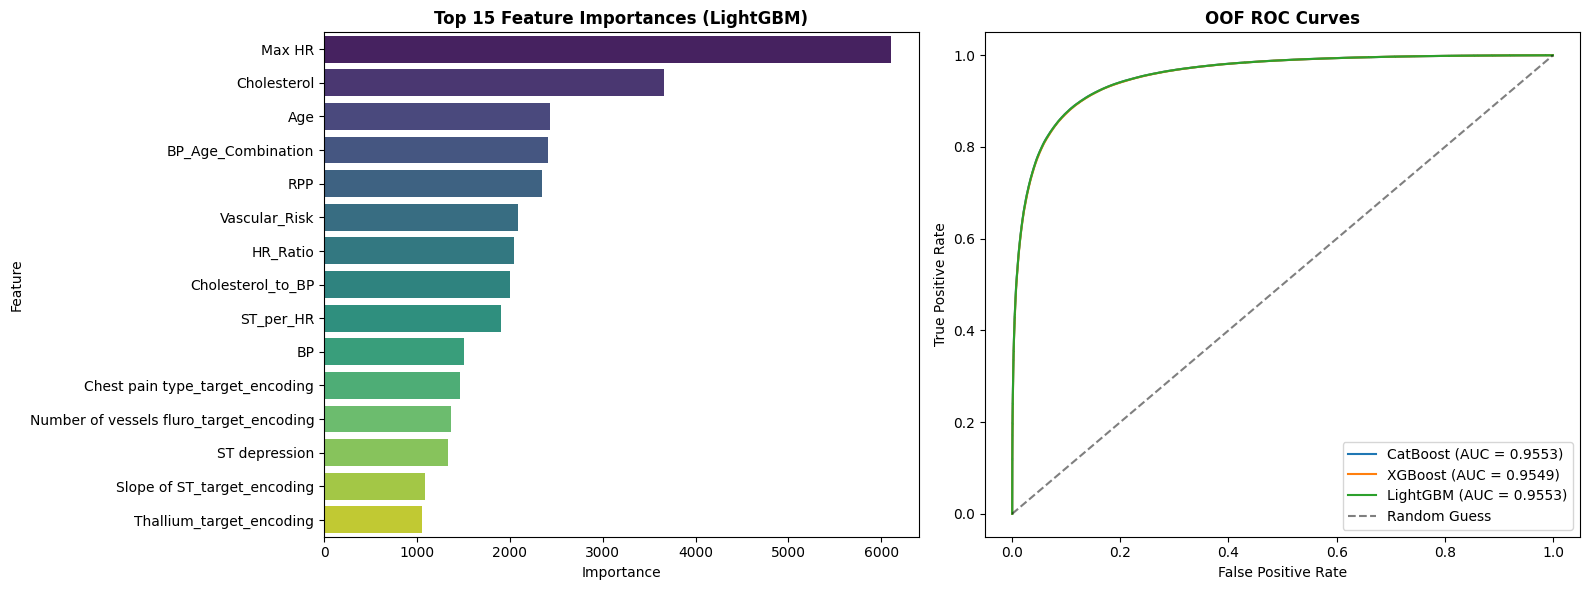

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Feature Importances (Top 15)
importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_importances
}).sort_values(by='Importance', ascending=False).head(15)

sns.barplot(data=importances_df, x='Importance', y='Feature', ax=ax[0], palette='viridis')
ax[0].set_title("Top 15 Feature Importances (LightGBM)", fontweight='bold')

# Plot 2: ROC Curves
fpr_cb, tpr_cb, _ = roc_curve(y_train, oof_cb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_train, oof_xgb)
fpr_lgb, tpr_lgb, _ = roc_curve(y_train, oof_lgb)

ax[1].plot(fpr_cb, tpr_cb, label=f'CatBoost (AUC = {roc_auc_score(y_train, oof_cb):.4f})')
ax[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_train, oof_xgb):.4f})')
ax[1].plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_score(y_train, oof_lgb):.4f})')
ax[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guess')

ax[1].set_title("OOF ROC Curves", fontweight='bold')
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [44]:
print("\nTraining Meta-Model (Logistic Regression)...")
# Using Rankdata for stacking limits scale issues
train_stack = np.column_stack([
    rankdata(oof_cb) / len(oof_cb),
    rankdata(oof_xgb) / len(oof_xgb),
    rankdata(oof_lgb) / len(oof_lgb)
])

test_stack = np.column_stack([
    rankdata(test_cb) / len(test_cb),
    rankdata(test_xgb) / len(test_xgb),
    rankdata(test_lgb) / len(test_lgb)
])

# Meta model
meta_model = LogisticRegression(C=1.0, random_state=42, n_jobs=-1)
meta_model.fit(train_stack, y_train)

oof_final = meta_model.predict_proba(train_stack)[:, 1]
test_final = meta_model.predict_proba(test_stack)[:, 1]

print(f"\n🚀 FINAL STACKED CV AUC: {roc_auc_score(y_train, oof_final):.5f}")


Training Meta-Model (Logistic Regression)...

🚀 FINAL STACKED CV AUC: 0.95537


In [45]:
submission = pd.DataFrame({
    "id": test_fe['id'],
    'Heart Disease': test_final
})

submission.to_csv("submission.csv", index=False)
print("\nSUBMISSION SAVED: 'submission.csv'")


SUBMISSION SAVED: 'submission.csv'
